In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from timm import create_model
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

In [3]:
BATCH_SIZE = 16
EPOCHS = 30 
LR = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_ROOT = "./昆虫_split"
PATIENCE = 5
MIN_DELTA = 1e-4

In [4]:
# 训练集增强
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [5]:
# 测试集增强
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [6]:
# 加载 train / test
train_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT,"train"), transform=train_transform)
test_dataset  = datasets.ImageFolder(os.path.join(DATA_ROOT,"test"),  transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

num_classes = len(train_dataset.classes)
print(f"类别数：{num_classes} | 训练集：{len(train_dataset)} 张 | 测试集：{len(test_dataset)} 张")

类别数：10 | 训练集：16383 张 | 测试集：8313 张


In [7]:
#模型
model = create_model("swin_tiny_patch4_window7_224", pretrained=True, num_classes=num_classes)
model = model.to(DEVICE)

In [8]:
#优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [9]:
class EarlyStopping:
    def __init__(self, patience=PATIENCE, min_delta=MIN_DELTA):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_acc):
        if self.best_score is None:
            self.best_score = val_acc
        elif val_acc < self.best_score + self.min_delta:
            self.counter += 1
            print(f"早停计数器：{self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_acc
            self.counter = 0
        return self.early_stop

In [11]:
# 初始化早停实例
early_stopping = EarlyStopping()

In [13]:
# 训练循环 
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True  # 强制加载损坏/不完整图片，解决报错！
train_losses, train_accs = [], []
test_losses, test_accs = [], []
best_acc = 0.0

for epoch in range(EPOCHS):
    # 训练
    model.train()
    tl, ta, total = 0.0, 0, 0
    for x,y in tqdm(train_loader, desc=f"Epoch{epoch+1} 训练"):
        x,y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out,y)
        loss.backward()
        optimizer.step()

        tl += loss.item() * x.size(0)
        ta += (out.argmax(1)==y).sum().item()
        total += x.size(0)
    tl /= total
    ta /= total

    # 测试
    model.eval()
    vl, va, total = 0.0, 0, 0
    with torch.no_grad():
        for x,y in tqdm(test_loader, desc=f"Epoch{epoch+1} 测试"):
            x,y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss = criterion(out,y)
            vl += loss.item() * x.size(0)
            va += (out.argmax(1)==y).sum().item()
            total += x.size(0)
    vl /= total
    va /= total

    train_losses.append(tl)
    train_accs.append(ta)
    test_losses.append(vl)
    test_accs.append(va)

    # 保存最优模型
    if va > best_acc:
        best_acc = va
        torch.save(model.state_dict(), "swin_best_final.pth")
        print(f"✅ 最优模型更新！测试精度：{va:.4f}")

    scheduler.step()
    print(f"📊 Epoch {epoch+1:2d} | Train Acc {ta:.4f} | Test Acc {va:.4f} | Best {best_acc:.4f}")

    # 早停
    if early_stopping(va):
        print("\n⚠️  提前停止训练")
        break

Epoch1 测试: 100%|██████████| 520/520 [02:47<00:00,  3.10it/s]


✅ 最优模型更新！测试精度：0.9260
📊 Epoch  1 | Train Acc 0.9521 | Test Acc 0.9260 | Best 0.9260


Epoch2 测试: 100%|██████████| 520/520 [02:44<00:00,  3.16it/s]


📊 Epoch  2 | Train Acc 0.9675 | Test Acc 0.9162 | Best 0.9260
早停计数器：1/5


Epoch3 测试: 100%|██████████| 520/520 [02:45<00:00,  3.14it/s]


...

📊 Epoch 21 | Train Acc 0.9997 | Test Acc 0.9384 | Best 0.9411
早停计数器：3/5


Epoch22 测试: 100%|██████████| 520/520 [02:44<00:00,  3.16it/s]


📊 Epoch 22 | Train Acc 0.9997 | Test Acc 0.9371 | Best 0.9411
早停计数器：4/5


Epoch23 测试: 100%|██████████| 520/520 [03:14<00:00,  2.68it/s]

📊 Epoch 23 | Train Acc 0.9993 | Test Acc 0.9405 | Best 0.9411
早停计数器：5/5

⚠️  提前停止训练


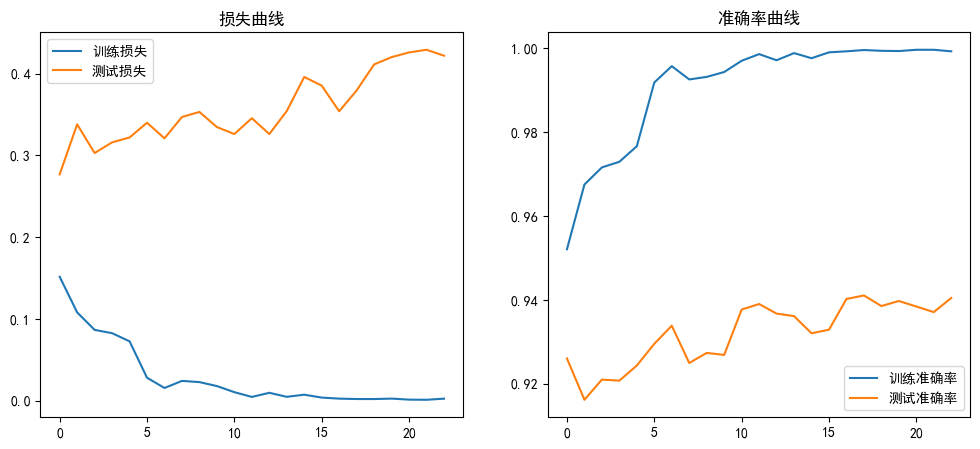


🎉 训练完成！最高测试精度：0.9411


In [14]:
# 绘图
plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus']=False
plt.figure(figsize=(12,5))
plt.subplot(121)
plt.plot(train_losses, label="训练损失")
plt.plot(test_losses, label="测试损失")
plt.title("损失曲线")
plt.legend()

plt.subplot(122)
plt.plot(train_accs, label="训练准确率")
plt.plot(test_accs, label="测试准确率")
plt.title("准确率曲线")
plt.legend()
plt.show()

print(f"\n🎉 训练完成！最高测试精度：{best_acc:.4f}")